In [ ]:
import numpy as np
import matplotlib.pyplot as plt



In [7]:
def rbf(r2, eps):
    return np.exp(-eps ** 2 * r2)

def rbf_laplacian(dx, dy, eps):
    r2 = dx ** 2 + dy ** 2
    return 2*eps**2 * rbf(r2, eps) * (2*eps**2 * r2 - 2)



In [10]:
def make_points(n_interior_1d, n_boundary_per_side=12):
   
   # Interior points
   xi = np.linspace(0, 1, n_interior_1d + 2)[1:-1]
   Xg, Yg = np.meshgrid(xi, xi)
   interor_points = np.column_stack([Xg.ravel(), Yg.ravel()])

   #Boundary points
   t = np.linspace(0, 1, n_boundary_per_side + 2)[1:-1]
   corners = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
   bottom = np.column_stack([t, np.zeros_like(t)])
   top = np.column_stack([t, np.ones_like(t)])
   left = np.column_stack([np.zeros_like(t), t])
   right = np.column_stack([np.ones_like(t), t])
   boundary_points = np.vstack([corners, bottom, top, left, right])

   # Combine interior and boundary points
   points = np.vstack([interor_points, boundary_points])
   is_boundary = [False] * len(interor_points) + [True] * len(boundary_points)
   return points, is_boundary

In [13]:
def assemble(points, is_boundary, eps, f, g):
    n = len(points)
    A = np.zeros((n, n))
    b = np.zeros(n)
    for i in range(n):
        xi, yi = points[i]

        if is_boundary[i]:
            b[i] = g(xi, yi)
            for j in range(n):
                xj, yj = points[j]
                dx = xi - xj
                dy = yi - yj
                A[i, j] = rbf(dx**2 + dy**2, eps)
        else:
            b[i] = f(xi, yi)
            for j in range(n):
                xj, yj = points[j]
                dx = xi - xj
                dy = yi - yj
                A[i, j] = rbf_laplacian(dx, dy, eps)

    return A, b



In [62]:
# Test 

f = lambda x, y: -2.0 * np.pi ** 2 * np.sin(np.pi * x) * np.sin(np.pi * y)
g = lambda x, y: 0.0
alpha = 1e-10
points, is_boundary = make_points(n_interior_1d=15)
A, b = assemble(points, is_boundary, eps=2.0, f=f, g=g)
A += alpha * np.eye(len(A))



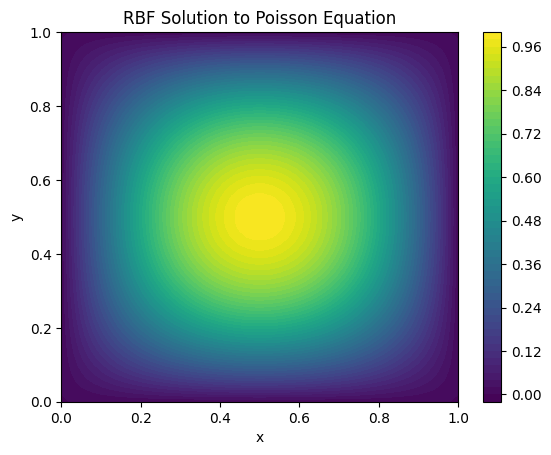

In [ ]:
lambdas = np.linalg.solve(A, b)


xi = np.linspace(0, 1, 50)
Xg, Yg = np.meshgrid(xi, xi)
solution = np.zeros_like(Xg)
for i in range(len(points)):
    dx = Xg - points[i, 0]
    dy = Yg - points[i, 1]
    solution += lambdas[i] * rbf(dx**2 + dy**2, eps=2.0)
plt.contourf(Xg, Yg, solution, levels=50, cmap='viridis')
plt.colorbar()
plt.title('RBF Solution to Poisson Equation')
plt.xlabel('x')
plt.ylabel('y')
plt.show()